# Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, f1_score


In [4]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/extended_stress_detection_data.csv')

Mounted at /content/drive


# Exploratory Data Analysis

In [5]:
#first 5 lines of dataset
df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
0,30.0,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8.0,1.0,5.0,Yes,Cardio,120.0,180.0,90.0,Low
1,35.0,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,No,9.0,2.0,3.0,No,Yoga,110.0,160.0,80.0,Medium
2,40.0,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8.0,1.0,5.0,Yes,Strength Training,130.0,200.0,100.0,High
3,35.0,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8.0,1.0,5.0,Yes,Cardio,120.0,180.0,90.0,Low
4,29.0,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,No,7.0,1.0,4.0,Yes,Yoga,110.0,180.0,90.0,Low


In [6]:
#number of columns and rows
df.shape

(3000, 22)

In [7]:
#prints summary of features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  3000 non-null   float64
 1   Gender               3000 non-null   object 
 2   Occupation           3000 non-null   object 
 3   Marital_Status       3000 non-null   object 
 4   Sleep_Duration       3000 non-null   float64
 5   Sleep_Quality        3000 non-null   float64
 6   Wake_Up_Time         3000 non-null   object 
 7   Bed_Time             3000 non-null   object 
 8   Physical_Activity    3000 non-null   float64
 9   Screen_Time          3000 non-null   float64
 10  Caffeine_Intake      3000 non-null   int64  
 11  Alcohol_Intake       3000 non-null   int64  
 12  Smoking_Habit        3000 non-null   object 
 13  Work_Hours           3000 non-null   float64
 14  Travel_Time          3000 non-null   float64
 15  Social_Interactions  3000 non-null   f

In [8]:
#central tendency, dispersion and shape
df.describe()

,Age,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Work_Hours,Travel_Time,Social_Interactions,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,38.846530,6.317590,3.871413,2.959787,4.064293,1.807667,0.875333,8.249623,2.836517,3.175870,138.011590,220.734257,111.690300
std,7.586693,1.137913,0.989186,1.180590,1.167995,0.825168,0.663278,1.354493,1.371720,1.224617,13.160897,18.976226,12.323205
min,16.980000,1.920000,0.520000,-1.340000,-0.440000,0.000000,0.000000,3.280000,-1.670000,-0.820000,109.130000,150.000000,78.250000
25%,33.097500,5.700000,3.220000,2.097500,3.210000,1.000000,0.000000,7.310000,1.960000,2.260000,126.600000,210.437500,104.890000
50%,38.735000,6.300000,3.900000,3.000000,4.000000,2.000000,1.000000,8.050000,2.970000,3.040000,137.020000,220.525000,113.930000
75%,44.470000,7.000000,4.430000,3.852500,5.000000,2.000000,1.000000,9.000000,4.000000,4.000000,149.942500,230.522500,120.000000
max,60.840000,10.160000,7.730000,7.210000,8.640000,4.000000,2.000000,14.000000,7.270000,7.500000,170.000000,290.000000,151.670000


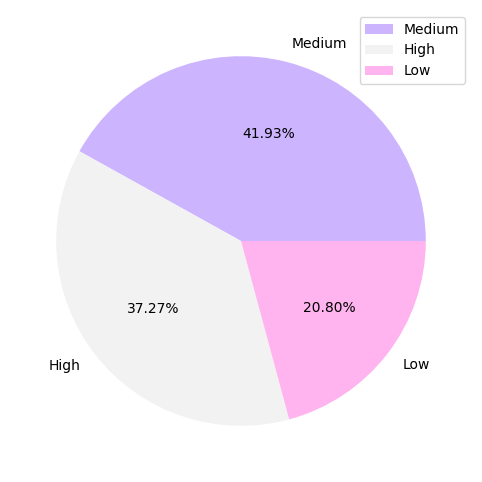

In [9]:
#Pie Chart of Number of Low, Medium high stress results
plt.figure(figsize=(10,6))
plt.pie(df['Stress_Detection'].value_counts().values,labels=df['Stress_Detection'].value_counts().index,autopct="%1.2f%%",colors=['#cdb4ff','#f2f2f2', '#ffb4ef'])
plt.legend()
plt.show()

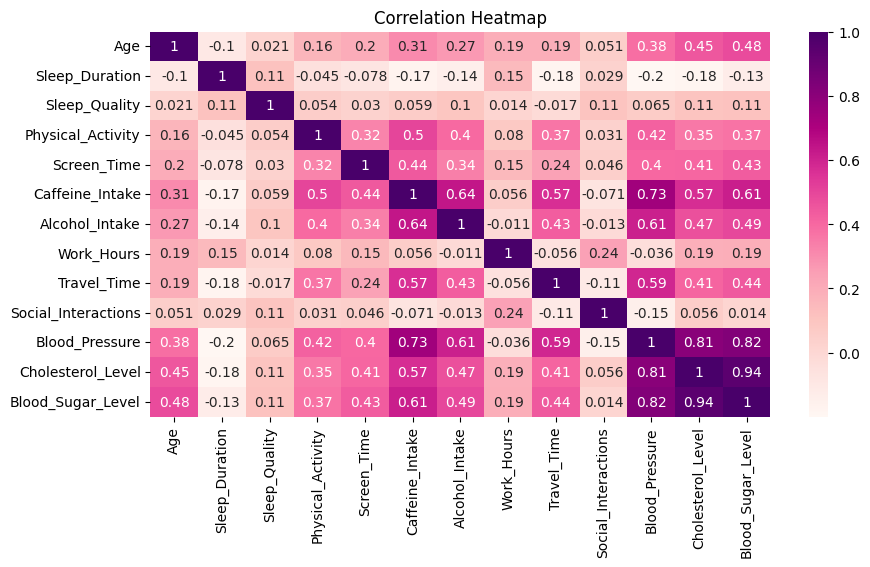

In [10]:
#heatmap shows how features relate
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="RdPu")
plt.title("Correlation Heatmap")
plt.show()

## Feature EDA

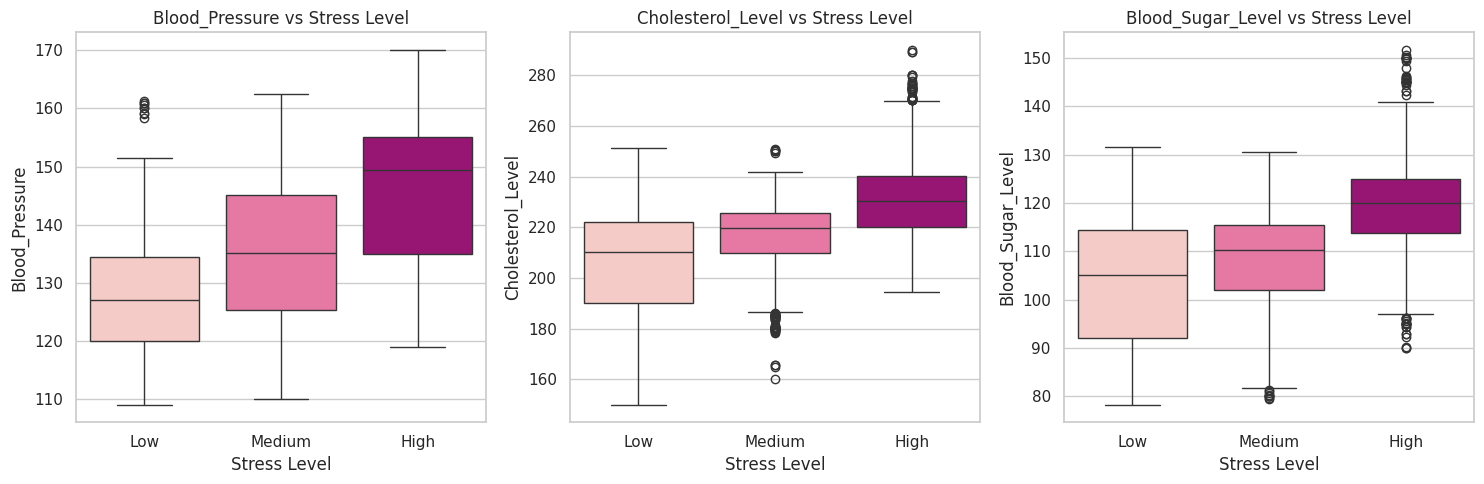

In [11]:
# Set style
sns.set(style="whitegrid")

# Biological marker columns
bio_cols = ["Blood_Pressure", "Cholesterol_Level", "Blood_Sugar_Level"]

# Create subplots
plt.figure(figsize=(15, 5))

for i, col in enumerate(bio_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x="Stress_Detection", y=col, hue="Stress_Detection", palette=sns.color_palette('RdPu', n_colors=3), legend=False)
    plt.title(f"{col} vs Stress Level")
    plt.xlabel("Stress Level")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

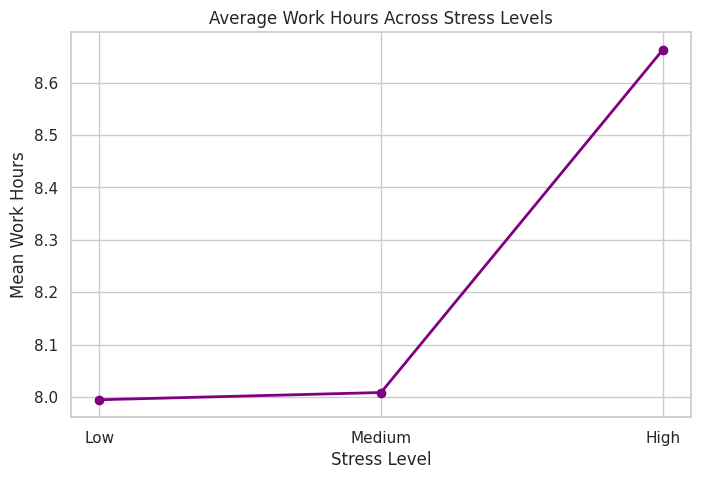

In [12]:
df["Stress_Detection"] = pd.Categorical(
    df["Stress_Detection"],
    categories=["Low", "Medium", "High"],
    ordered=True
)

# Compute mean Work Hours per stress category with observed=False to suppress warning
work_hours_mean = df.groupby("Stress_Detection", observed=False)["Work_Hours"].mean()

# Line plot
plt.figure(figsize=(8, 5))
plt.plot(work_hours_mean.index, work_hours_mean.values, marker='o', linewidth=2, color='purple')

plt.title("Average Work Hours Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Mean Work Hours")
plt.grid(True)
plt.show()

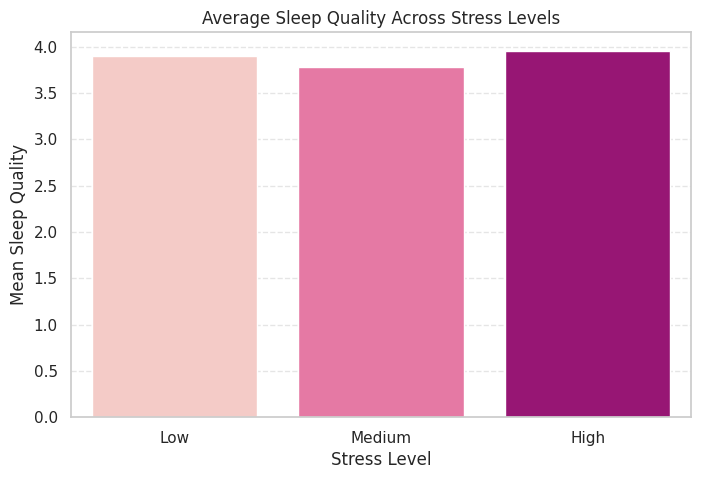

In [13]:
# Compute mean sleep quality per stress level with observed=False to suppress warning
sleep_quality_mean = df.groupby("Stress_Detection", observed=False)["Sleep_Quality"].mean().reset_index()

# Plot grouped bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    data=sleep_quality_mean,
    x="Stress_Detection",
    y="Sleep_Quality",
    hue="Stress_Detection",
    palette=sns.color_palette('RdPu', n_colors=3),
    legend=False
)

plt.title("Average Sleep Quality Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Mean Sleep Quality")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

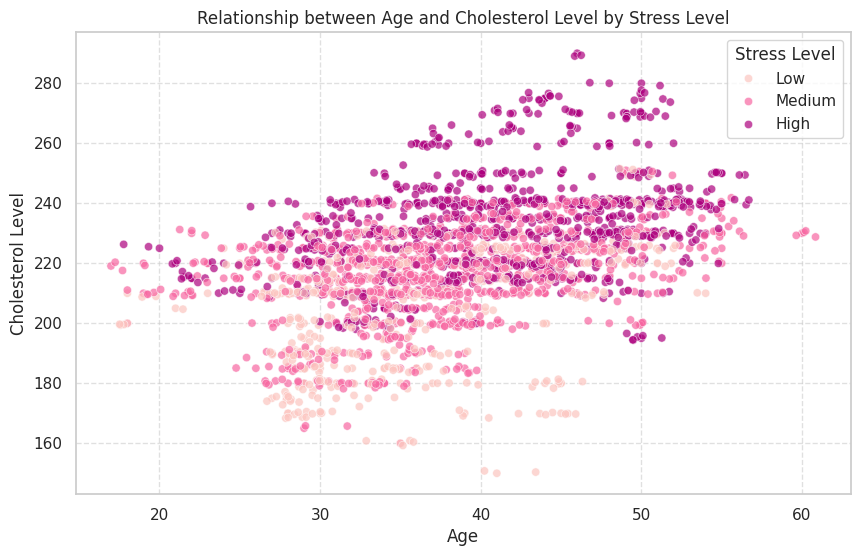

In [14]:
# Ensure Stress_Detection is ordered for the legend
if not isinstance(df['Stress_Detection'].dtype, pd.CategoricalDtype):
    df['Stress_Detection'] = pd.Categorical(df['Stress_Detection'], categories=['Low', 'Medium', 'High'], ordered=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Cholesterol_Level', hue='Stress_Detection', palette='RdPu', alpha=0.7)

plt.title('Relationship between Age and Cholesterol Level by Stress Level')
plt.xlabel('Age')
plt.ylabel('Cholesterol Level')
plt.legend(title='Stress Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Preprocessing

In [15]:
#prints list of features with missing values
df.isnull().sum()

,0
Age,0
Gender,0
Occupation,0
Marital_Status,0
Sleep_Duration,0
Sleep_Quality,0
Wake_Up_Time,0
Bed_Time,0
Physical_Activity,0
Screen_Time,0


In [16]:
#checks for duplicates - True means duplicate
duplicates = df.duplicated()
print(duplicates.value_counts())

False    3000
Name: count, dtype: int64


In [17]:
physiological_features = [
    'Sleep_Duration', 'Sleep_Quality',
    'Blood_Pressure', 'Cholesterol_Level',
    'Blood_Sugar_Level', 'Caffeine_Intake',
    'Alcohol_Intake', 'Smoking_Habit'
]

social_features = [
    'Work_Hours', 'Travel_Time',
    'Social_Interactions', 'Occupation'
]

activity_features = [
    'Physical_Activity', 'Screen_Time',
    'Meditation_Practice'
]


## Encoding

In [18]:
le = LabelEncoder()
y = le.fit_transform(df["Stress_Detection"])

# Set future behavior to avoid warnings
pd.set_option('future.no_silent_downcasting', True)

# Maps binary categories to 0/1
df['Gender'] = df['Gender'].replace({'Male': 1, 'Female': 0}).infer_objects(copy=False)
df['Smoking_Habit'] = df['Smoking_Habit'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
df['Meditation_Practice'] = df['Meditation_Practice'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)

# One-hot encode multiclass categories
df_encoded = pd.get_dummies(df, columns=['Marital_Status', 'Exercise_Type'])

# Define feature set X, dropping target and non-numeric time strings
X = df_encoded.drop(["Stress_Detection", "Wake_Up_Time", "Bed_Time"], axis=1)

## Splitting dataset

In [19]:
# Initial split: 85% for train/val, 15% for test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

#Second split: from the 85%, take 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (2099, 27)
Validation: (451, 27)
Testing: (450, 27)


## Last Encoding

In [20]:
# Target Encoding for Occupation (performed AFTER split to prevent leakage)
# calculate the mean target value using only the training data
occupation_means = X_train.assign(target=y_train).groupby('Occupation')['target'].mean()
global_mean = y_train.mean()

# Maps these means to all sets and fill missing values using the global mean
X_train['Occupation'] = X_train['Occupation'].map(occupation_means)
X_val['Occupation'] = X_val['Occupation'].map(occupation_means).fillna(global_mean)
X_test['Occupation'] = X_test['Occupation'].map(occupation_means).fillna(global_mean)

display(X_train[['Occupation']].head())

,Occupation
1884,1.375000
280,1.031250
1110,0.000000
974,1.219512
1569,1.428571


## Scaling

In [21]:
# columns with significant outliers
robust_cols = ['Cholesterol_Level', 'Work_Hours', 'Blood_Sugar_Level']
robust_scaler = RobustScaler()

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_val[robust_cols] = robust_scaler.transform(X_val[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

In [22]:
# columns without significant outliers
standard_cols = [
    'Age', 'Sleep_Duration', 'Sleep_Quality', 'Physical_Activity',
    'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake',
    'Travel_Time', 'Social_Interactions', 'Blood_Pressure'
]

standard_scaler = StandardScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_val[standard_cols] = standard_scaler.transform(X_val[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

## Linear equation implementation

In [23]:
#creates averages of each factor for linear equation
for split in [(X_train, "train"), (X_val, "val"), (X_test, "test")]:
    X, name = split

    X["x_phys"] = X[physiological_features].mean(axis=1)
    X["y_social"] = X[social_features].mean(axis=1)
    X["z_activity"] = X[activity_features].mean(axis=1)


In [24]:
#Fits model using previous averages for each factor
#Then extracts weights for each
lin_reg = LinearRegression()

X_lin_train = X_train[["x_phys", "y_social", "z_activity"]]
lin_reg.fit(X_lin_train, y_train)

a, b, c = lin_reg.coef_

print(f"S = {a:.3f}x + {b:.3f}y + {c:.3f}z")

S = -0.422x + -0.063y + -0.264z


In [25]:
#function created where it creates a single 'Stress_Score' based on
#previous weights
#New column is made
def compute_stress_score(X):
    return a*X["x_phys"] + b*X["y_social"] + c*X["z_activity"]

X_train["Stress_Score"] = compute_stress_score(X_train)
X_val["Stress_Score"] = compute_stress_score(X_val)
X_test["Stress_Score"] = compute_stress_score(X_test)


In [26]:
#Cleans up dataset and reduces noise for algorithms
X_train_final = X_train.drop(["x_phys", "y_social", "z_activity"], axis=1)
X_val_final = X_val.drop(["x_phys", "y_social", "z_activity"], axis=1)
X_test_final = X_test.drop(["x_phys", "y_social", "z_activity"], axis=1)

In [27]:
X_train_final.head()

,Age,Gender,Occupation,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Smoking_Habit,...,Marital_Status_Married,Marital_Status_Single,Exercise_Type_Aerobics,Exercise_Type_Cardio,Exercise_Type_Meditation,Exercise_Type_Pilates,Exercise_Type_Strength Training,Exercise_Type_Walking,Exercise_Type_Yoga,Stress_Score
1884,-0.418102,0,1.375000,0.394644,-1.104117,-0.492974,0.779938,-0.959468,0.20925,1,...,True,False,False,True,False,False,False,False,False,-0.081099
280,1.348335,1,1.031250,0.587223,1.163158,0.063050,-0.053130,0.255935,0.20925,1,...,False,True,False,True,False,False,False,False,False,-0.307687
1110,-0.887560,1,0.000000,-0.787087,-0.758434,1.748232,2.641590,1.471339,0.20925,1,...,False,True,False,False,False,False,True,False,False,-0.749981
974,-0.571936,1,1.219512,-0.489466,0.654800,-1.314179,-2.909364,0.255935,0.20925,1,...,False,True,False,False,False,False,True,False,False,0.243210
1569,-0.506954,1,1.428571,-1.338561,0.044771,1.474497,0.465412,0.255935,0.20925,1,...,True,False,False,True,False,False,False,False,False,-0.326046


# Training models


In [28]:
def plot_confusion_matrix_custom(y_true, y_pred, labels, title="Confusion Matrix"):
    """
    Plots a confusion matrix.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        labels (list): List of class labels for display.
        title (str): Title of the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Purples')
    plt.title(title)
    plt.show()

## Random Forest

Random Forest Accuracy: 0.9046563192904656

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       168
           1       0.96      0.82      0.89        94
           2       0.87      0.94      0.90       189

    accuracy                           0.90       451
   macro avg       0.92      0.89      0.90       451
weighted avg       0.91      0.90      0.90       451



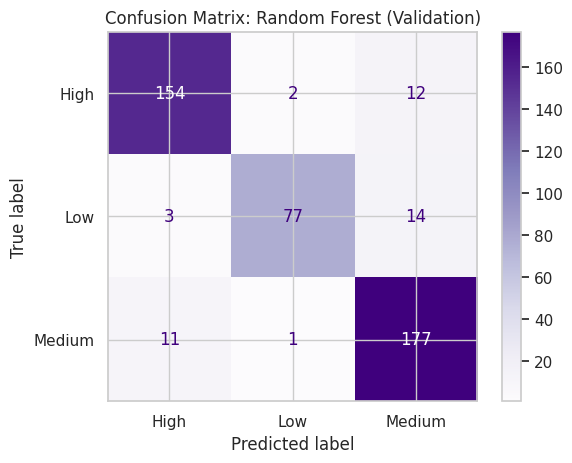

In [29]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the Stress_Score derived from the linear equation
rf_model.fit(X_train_final, y_train)

# Make predictions on the validation set
y_val_pred = rf_model.predict(X_val_final)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# Plot Confusion Matrix
plot_confusion_matrix_custom(y_val, y_val_pred, le.classes_, title="Confusion Matrix: Random Forest (Validation)")

In [30]:
# 2. Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 3. Initialize classifier
rf = RandomForestClassifier(random_state=42)

# 4. Instantiate GridSearchCV
rf_grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')

# 5. Fit using validation data
rf_grid_search.fit(X_train_final, y_train)


# 6. Print results
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best Score: {rf_grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.8709


Final Test Accuracy: 0.8711111111111111

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       168
           1       0.93      0.72      0.81        93
           2       0.84      0.92      0.88       189

    accuracy                           0.87       450
   macro avg       0.88      0.85      0.86       450
weighted avg       0.88      0.87      0.87       450



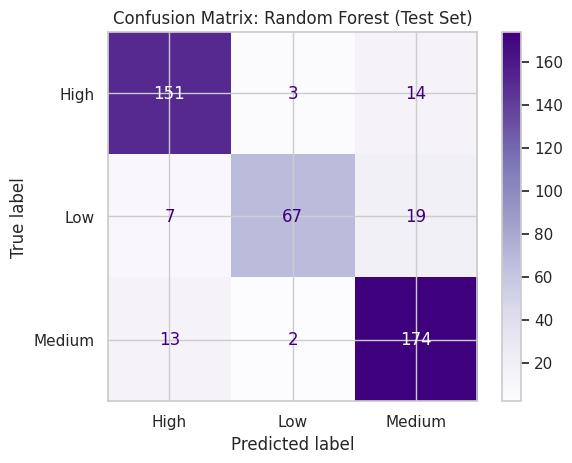

In [31]:
# Final evaluation on the test set
best_rf = rf_grid_search.best_estimator_

y_test_pred = best_rf.predict(X_test_final)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Confusion Matrix for Test Set
plot_confusion_matrix_custom(y_test, y_test_pred, le.classes_, title="Confusion Matrix: Random Forest (Test Set)")

## Decision Tree

Decision Tree Accuracy (Baseline): 0.7427937915742794

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       168
           1       0.64      0.52      0.58        94
           2       0.73      0.83      0.77       189

    accuracy                           0.74       451
   macro avg       0.73      0.71      0.71       451
weighted avg       0.74      0.74      0.74       451



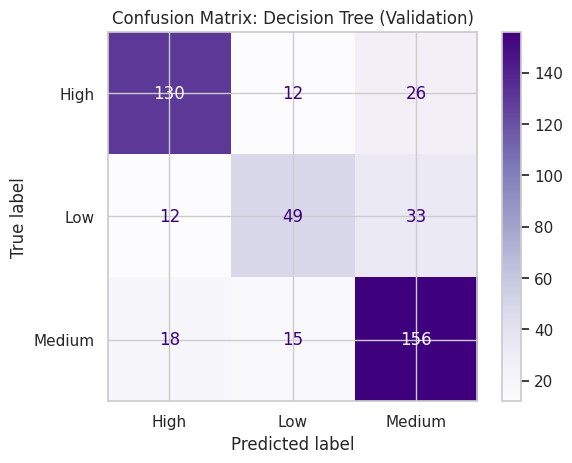

In [32]:
#Initial training on training Set
dt_model = DecisionTreeClassifier(max_depth=10,min_samples_leaf=5,random_state=42)

dt_model.fit(X_train_final, y_train)

y_val_pred_dt = dt_model.predict(X_val_final)

print("Decision Tree Accuracy (Baseline):", accuracy_score(y_val, y_val_pred_dt))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_dt))

# Plot Confusion Matrix for Validation Set
plot_confusion_matrix_custom(y_val, y_val_pred_dt, le.classes_, title="Confusion Matrix: Decision Tree (Validation)")

In [33]:
# Define parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)

# Instantiate GridSearchCV
dt_grid_search = GridSearchCV(estimator=dt_clf, param_grid=dt_param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV to training data
#Not Validation because used Cross-Validation and otherwise will learn baised Validation set
dt_grid_search.fit(X_train_final, y_train)

# Print results
print(f"Best Decision Tree Parameters: {dt_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {dt_grid_search.best_score_:.4f}")

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.8023


Final Test Accuracy: 0.8155555555555556

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       168
           1       0.70      0.69      0.70        93
           2       0.81      0.84      0.82       189

    accuracy                           0.82       450
   macro avg       0.80      0.80      0.80       450
weighted avg       0.82      0.82      0.82       450



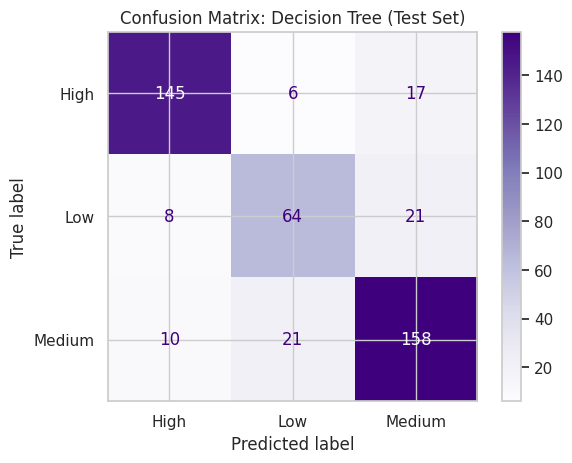

In [34]:
# Final evaluation on the test set
best_dt = dt_grid_search.best_estimator_

y_test_pred = best_dt.predict(X_test_final)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Confusion Matrix for Test Set
plot_confusion_matrix_custom(y_test, y_test_pred, le.classes_, title="Confusion Matrix: Decision Tree (Test Set)")

## SVM

--- SVM Performance ---
SVM (Baseline): 0.7804878048780488

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       168
           1       0.82      0.59      0.68        94
           2       0.74      0.84      0.79       189

    accuracy                           0.78       451
   macro avg       0.79      0.75      0.76       451
weighted avg       0.79      0.78      0.78       451



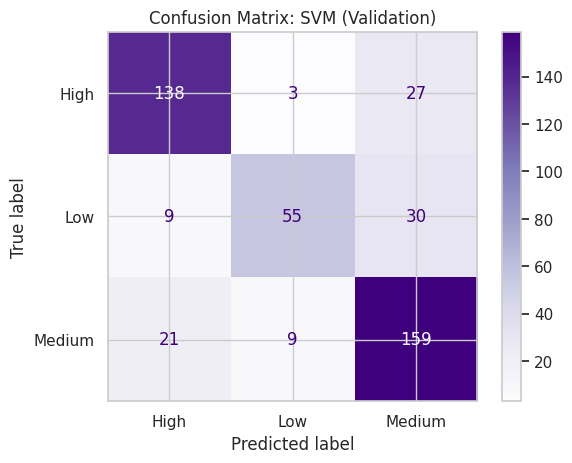

In [35]:
# Initialize classifiers
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Train models
svm_model.fit(X_train_final, y_train)

# Evaluate SVM
y_val_pred_svm = svm_model.predict(X_val_final)
print("--- SVM Performance ---")
print("SVM (Baseline):", accuracy_score(y_val, y_val_pred_svm))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_svm))

# Plot Confusion Matrix for Validation Set
plot_confusion_matrix_custom(y_val, y_val_pred_svm, le.classes_, title="Confusion Matrix: SVM (Validation)")

In [36]:
# Define parameter grid for SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Initialize Support Vector Classifier (NOT Decision Tree)
svm_clf = SVC(random_state=42)

# Instantiate GridSearchCV
svm_grid_search = GridSearchCV(estimator=svm_clf, param_grid=svm_param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV to the training data
svm_grid_search.fit(X_train_final, y_train)

# Print the results
print(f"Best SVM Parameters: {svm_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {svm_grid_search.best_score_:.4f}")

Best SVM Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8333


Final Test Accuracy: 0.8422222222222222

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       168
           1       0.80      0.71      0.75        93
           2       0.82      0.86      0.84       189

    accuracy                           0.84       450
   macro avg       0.84      0.82      0.83       450
weighted avg       0.84      0.84      0.84       450



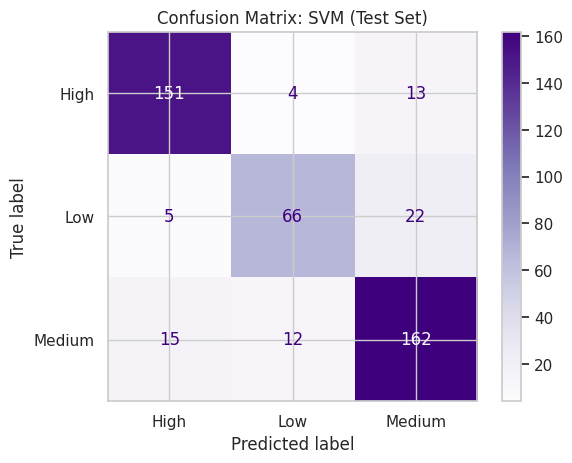

In [37]:
best_svm = svm_grid_search.best_estimator_

y_test_pred = best_svm.predict(X_test_final)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Confusion Matrix for Test Set
plot_confusion_matrix_custom(y_test, y_test_pred, le.classes_, title="Confusion Matrix: SVM (Test Set)")

## Neural network

ANN Accuracy (Baseline): 0.8381374722838137

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       168
           1       0.76      0.77      0.76        94
           2       0.83      0.85      0.84       189

    accuracy                           0.84       451
   macro avg       0.83      0.83      0.83       451
weighted avg       0.84      0.84      0.84       451



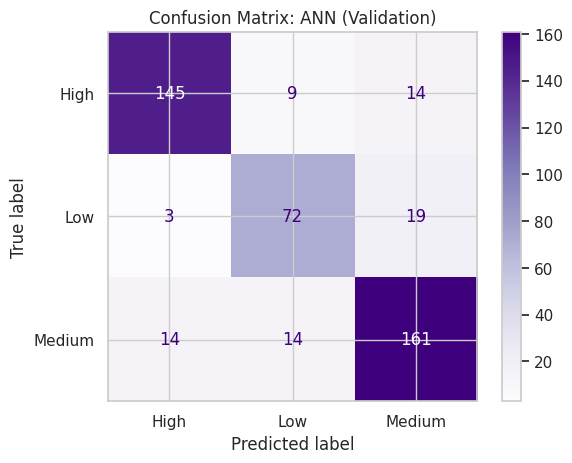

In [38]:
# Step 1: Initialize and train a baseline Neural Network
# Increased max_iter to 1000 to ensure convergence

ann_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

ann_model.fit(X_train_final, y_train)

y_val_pred_ann = ann_model.predict(X_val_final)

print("ANN Accuracy (Baseline):", accuracy_score(y_val, y_val_pred_ann))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_ann))

# Plot Confusion Matrix for Validation Set
plot_confusion_matrix_custom(y_val, y_val_pred_ann, le.classes_, title="Confusion Matrix: ANN (Validation)")

In [39]:
# Step 2: Hyperparameter Tuning using GridSearchCV
# Increasing max_iter further and enabling early_stopping to ensure convergence
ann_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'max_iter': [2000],
    'early_stopping': [False]
}

ann_grid_search = GridSearchCV(estimator=MLPClassifier(random_state=42), param_grid=ann_param_grid, cv=5, scoring='accuracy')
ann_grid_search.fit(X_train_final, y_train)

best_ann = ann_grid_search.best_estimator_
print(f"Best ANN Parameters: {ann_grid_search.best_params_}")
print(f"Tuned ANN Cross-Validation Score: {ann_grid_search.best_score_:.4f}")

Best ANN Parameters: {'activation': 'tanh', 'alpha': 0.001, 'early_stopping': False, 'hidden_layer_sizes': (100,), 'max_iter': 2000}
Tuned ANN Cross-Validation Score: 0.8233


Final Test Accuracy: 0.8266666666666667

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       168
           1       0.74      0.71      0.73        93
           2       0.83      0.84      0.83       189

    accuracy                           0.83       450
   macro avg       0.81      0.81      0.81       450
weighted avg       0.83      0.83      0.83       450



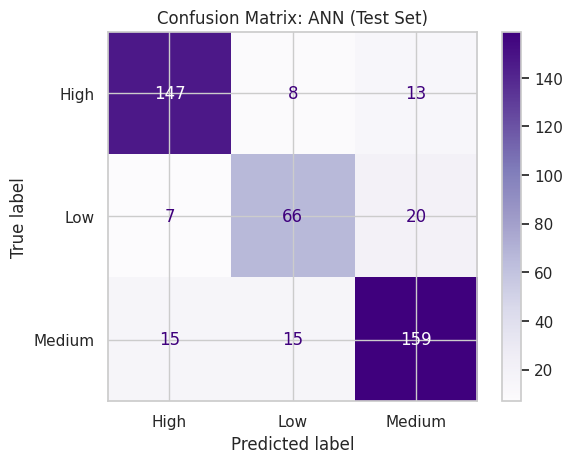

In [40]:
best_ann = ann_grid_search.best_estimator_

y_test_pred = best_ann.predict(X_test_final)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Confusion Matrix for Test Set
plot_confusion_matrix_custom(y_test, y_test_pred, le.classes_, title="Confusion Matrix: ANN (Test Set)")

## Gradient Boosting

--- Gradient Boosting Performance ---

Gradient boost (Baseline): 0.8048780487804879

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       168
           1       0.80      0.64      0.71        94
           2       0.78      0.88      0.82       189

    accuracy                           0.80       451
   macro avg       0.81      0.78      0.79       451
weighted avg       0.81      0.80      0.80       451



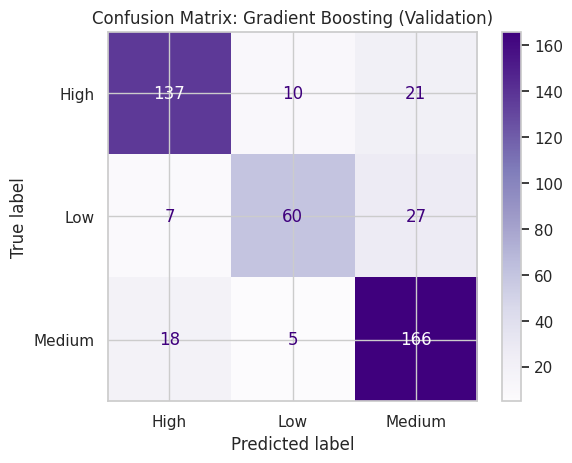

In [41]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb_model.fit(X_train_final, y_train)

# Evaluate Gradient Boosting
y_val_pred_gb = gb_model.predict(X_val_final)
print("--- Gradient Boosting Performance ---")
print("\nGradient boost (Baseline):", accuracy_score(y_val, y_val_pred_gb))
print("\nClassification Report:")
# Corrected to use y_val_pred_gb for the classification report of Gradient Boosting baseline
print(classification_report(y_val, y_val_pred_gb))

# Plot Confusion Matrix for Validation Set
plot_confusion_matrix_custom(y_val, y_val_pred_gb, le.classes_, title="Confusion Matrix: Gradient Boosting (Validation)")

In [42]:
# 1. Define the parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_leaf': [1, 3, 5]
}

# 2. Initialize the classifier
gb = GradientBoostingClassifier(random_state=42)

# 3. Instantiate GridSearchCV
gb_grid_search = GridSearchCV(estimator=gb, param_grid=gb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Fit to the training data
gb_grid_search.fit(X_train_final, y_train)

# 5. Print the results
print(f"Best Gradient Boosting Parameters: {gb_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {gb_grid_search.best_score_:.4f}")


Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Score: 0.8928


Final Test Accuracy: 0.8822222222222222

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       168
           1       0.89      0.80      0.84        93
           2       0.87      0.89      0.88       189

    accuracy                           0.88       450
   macro avg       0.88      0.87      0.88       450
weighted avg       0.88      0.88      0.88       450



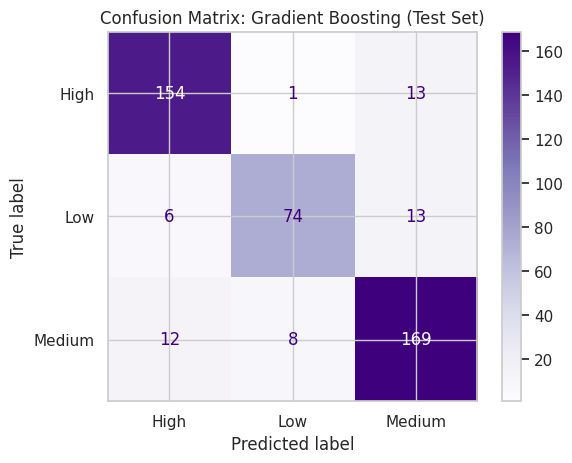

In [43]:
best_gb = gb_grid_search.best_estimator_

y_test_pred = best_gb.predict(X_test_final)
print("Final Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_test_pred))

# Plot Confusion Matrix for Test Set
plot_confusion_matrix_custom(y_test, y_test_pred, le.classes_, title="Confusion Matrix: Gradient Boosting (Test Set)")

# Best performing model

In [44]:
# Dictionary to store results
results = {}

# List of our best models
models = {
    'Random Forest': best_rf,
    'Decision Tree': best_dt,
    'SVM': svm_grid_search.best_estimator_,
    'Gradient Boosting': gb_grid_search.best_estimator_,
    'Neural Network' : best_ann
}

print("--- Final Test Set Performance ---\n")
for name, model in models.items():
    y_pred = model.predict(X_test_final)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"{name}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

# Identify the best model
best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
print(f"\n The overall champion is: {best_model_name}")

--- Final Test Set Performance ---

Random Forest: Accuracy = 0.8711, F1-Score = 0.8695
Decision Tree: Accuracy = 0.8156, F1-Score = 0.8156
SVM: Accuracy = 0.8422, F1-Score = 0.8410
Gradient Boosting: Accuracy = 0.8822, F1-Score = 0.8817
Neural Network: Accuracy = 0.8267, F1-Score = 0.8261

 The overall champion is: Gradient Boosting


# Feature Importance

In [45]:
# 1. Access feature importances
importances = best_gb.feature_importances_

# 2. Retrieve feature names
feature_names = X_train_final.columns

# 3. Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the top features
print("Top 10 Most Influential Features (Gradient Boosting):")
display(feature_importance_df.head(10))

Top 10 Most Influential Features (Gradient Boosting):


,Feature,Importance
0,Occupation,0.209909
1,Stress_Score,0.162040
2,Cholesterol_Level,0.112402
3,Blood_Pressure,0.081500
4,Age,0.077244
5,Blood_Sugar_Level,0.070119
6,Alcohol_Intake,0.034549
7,Caffeine_Intake,0.024801
8,Social_Interactions,0.022516
9,Work_Hours,0.018195


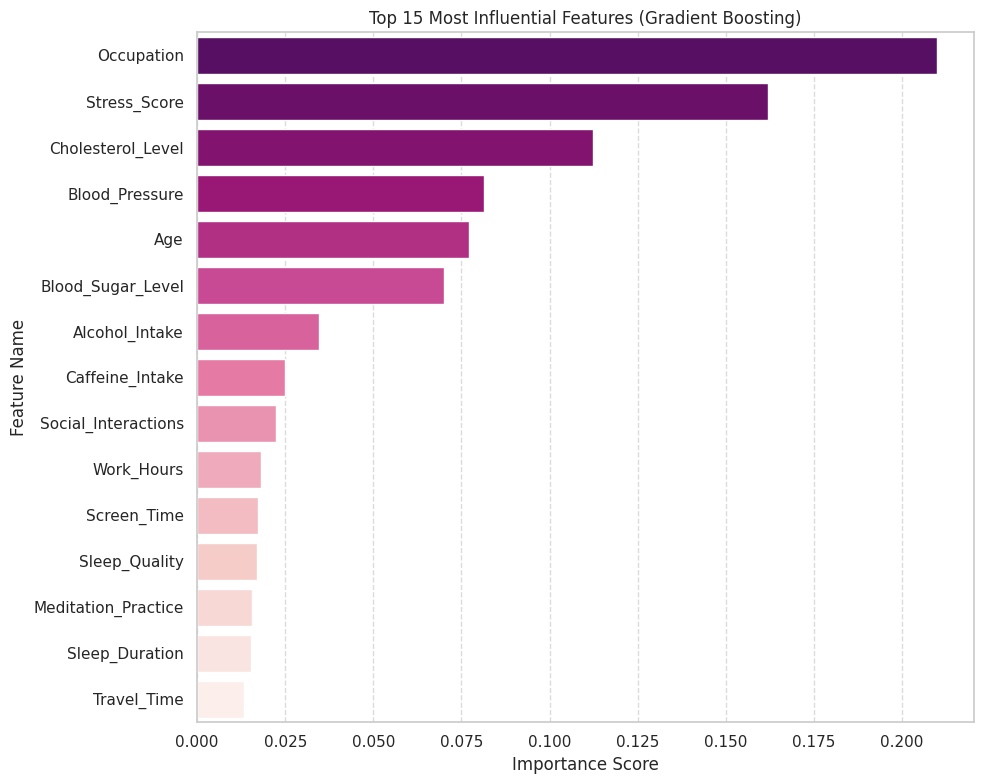

In [46]:

# Set the figure size
plt.figure(figsize=(10, 8))

# Create horizontal bar chart
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(15), # Showing top 15 features
    hue="Feature",
    palette="RdPu_r",
    legend=False
)

# Add titles and labels
plt.title("Top 15 Most Influential Features (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [47]:
# 1. Access feature importances from the best_rf model
rf_importances = best_rf.feature_importances_

# 2. Retrieve feature names from the training columns
rf_feature_names = X_train_final.columns

# 3. Construct the importance DataFrame
rf_feature_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
})

# 4. Sort in descending order
rf_feature_importance_df = rf_feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 5. Display the top 10 most influential features
print("Top 10 Most Influential Features (Random Forest):")
display(rf_feature_importance_df.head(10))

Top 10 Most Influential Features (Random Forest):


,Feature,Importance
0,Occupation,0.143274
1,Stress_Score,0.098731
2,Cholesterol_Level,0.094879
3,Blood_Sugar_Level,0.076825
4,Blood_Pressure,0.073520
5,Age,0.063583
6,Caffeine_Intake,0.043162
7,Screen_Time,0.038331
8,Sleep_Duration,0.035503
9,Work_Hours,0.035018


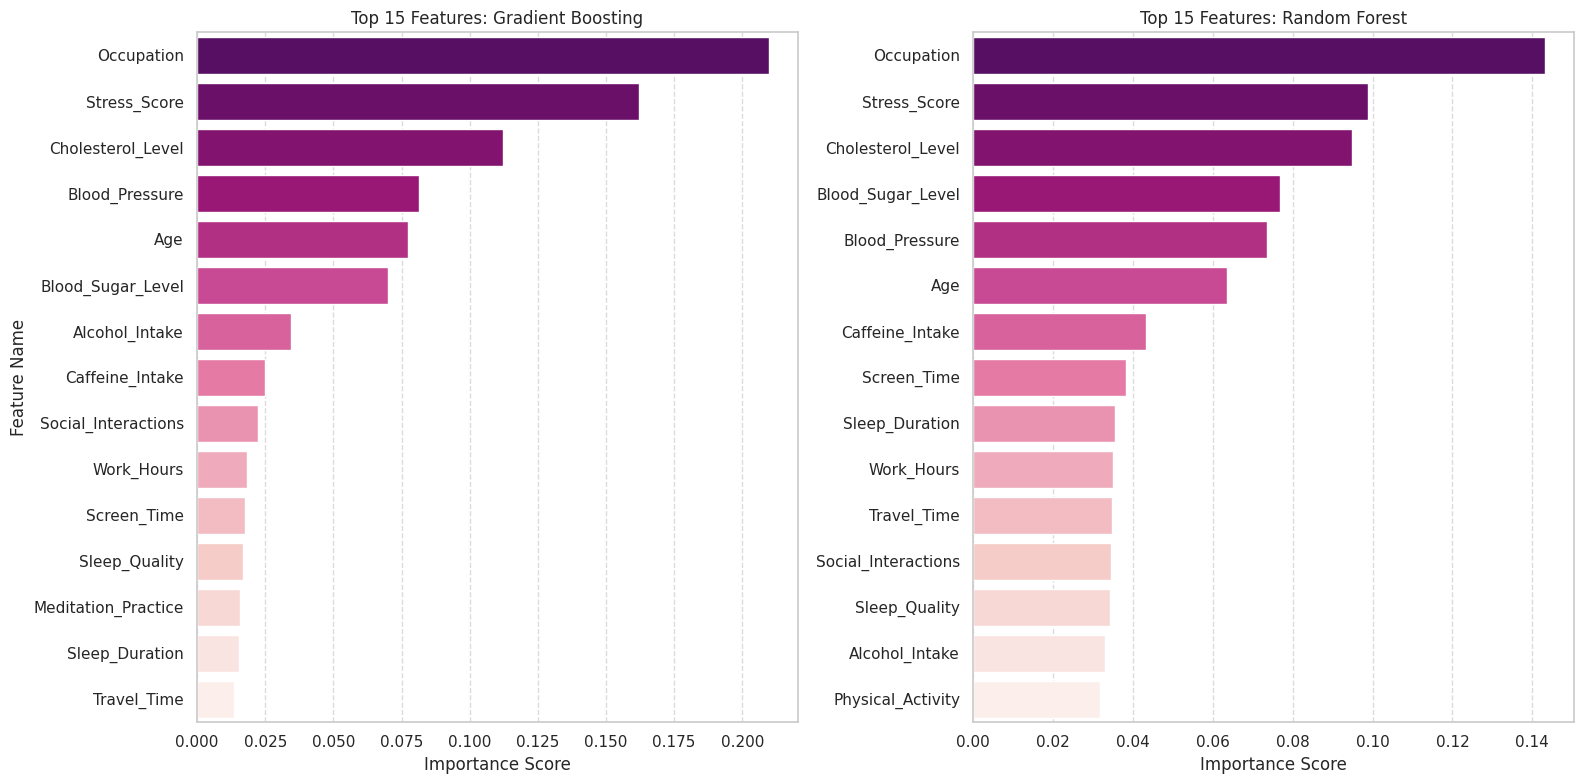

In [48]:
# 1. Define the number of top features to display
top_n = 15

# 2. Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 3. First subplot: Gradient Boosting
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(top_n),
    ax=axes[0],
    hue="Feature",
    palette="RdPu_r",
    legend=False
)
axes[0].set_title(f"Top {top_n} Features: Gradient Boosting")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Feature Name")
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# 4. Second subplot: Random Forest
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_feature_importance_df.head(top_n),
    ax=axes[1],
    hue="Feature",
    palette="RdPu_r",
    legend=False
)
axes[1].set_title(f"Top {top_n} Features: Random Forest")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("") # Remove y-label for the second plot for better layout
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

# 5. Final layout adjustments
plt.tight_layout()
plt.show()

In [49]:
import pandas as pd

#  1. Create a sample new DataFrame (replace with your actual new data)
# This new data needs to have the same columns as original df before preprocessing
new_data = {
    'Age': [32.0],
    'Gender': [1], # Male
    'Occupation': ['Software Engineer'],
    'Marital_Status': ['Single'],
    'Sleep_Duration': [7.5],
    'Sleep_Quality': [4.0],
    'Wake_Up_Time': ['7:00 AM'],
    'Bed_Time': ['10:00 PM'],
    'Physical_Activity': [2.5],
    'Screen_Time': [3.0],
    'Caffeine_Intake': [1],
    'Alcohol_Intake': [0],
    'Smoking_Habit': [0],
    'Work_Hours': [8.0],
    'Travel_Time': [1.5],
    'Social_Interactions': [4.0],
    'Meditation_Practice': [1],
    'Exercise_Type': ['Cardio'],
    'Blood_Pressure': [125.0],
    'Cholesterol_Level': [190.0],
    'Blood_Sugar_Level': [95.0]
}
new_df = pd.DataFrame(new_data)

# Keep track of original new_df for comparison if needed
original_new_df = new_df.copy()

# 2. Reapply preprocessing steps to new_df


pd.set_option('future.no_silent_downcasting', True)

# 2.1. Binary Encoding (using .replace() done before)
new_df['Gender'] = new_df['Gender'].replace({'Male': 1, 'Female': 0}).infer_objects(copy=False)
new_df['Smoking_Habit'] = new_df['Smoking_Habit'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
new_df['Meditation_Practice'] = new_df['Meditation_Practice'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)

# 2.2. One-hot encode multiclass categories (Marital_Status, Exercise_Type)
# Use pd.get_dummies and reindex to consistent columns with X_train_final
new_df_encoded = pd.get_dummies(new_df, columns=['Marital_Status', 'Exercise_Type'])

# Drop non-numeric time strings and target (if it exists, though for new data it won't)
X_new_processed = new_df_encoded.drop(["Wake_Up_Time", "Bed_Time"], axis=1)

# Recalculate occupation_means and global_mean within this cell to ensure they are defined
# This assumes X_train and y_train are available in the kernel state, which they should be after previous executions.
# If they are not, they would need to be reloaded/recreated here as well.
occupation_means = X_train.assign(target=y_train).groupby('Occupation')['target'].mean()
global_mean = y_train.mean()

# 2.3. Target Encoding for Occupation
# Use the 'occupation_means' and 'global_mean' calculated from the training data
X_new_processed['Occupation'] = X_new_processed['Occupation'].map(occupation_means).fillna(global_mean)

# 2.4. Scale numerical features using the *fitted* scalers
# Define the lists of columns again for clarity
physiological_features = [
    'Sleep_Duration', 'Sleep_Quality',
    'Blood_Pressure', 'Cholesterol_Level',
    'Blood_Sugar_Level', 'Caffeine_Intake',
    'Alcohol_Intake', 'Smoking_Habit'
]
social_features = [
    'Work_Hours', 'Travel_Time',
    'Social_Interactions', 'Occupation'
]
activity_features = [
    'Physical_Activity', 'Screen_Time',
    'Meditation_Practice'
]

robust_cols = ['Cholesterol_Level', 'Work_Hours', 'Blood_Sugar_Level']
standard_cols = [
    'Age', 'Sleep_Duration', 'Sleep_Quality', 'Physical_Activity',
    'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake',
    'Travel_Time', 'Social_Interactions', 'Blood_Pressure'
]

X_new_processed[robust_cols] = robust_scaler.transform(X_new_processed[robust_cols])
X_new_processed[standard_cols] = standard_scaler.transform(X_new_processed[standard_cols])

# 2.5. create 'x_phys', 'y_social', 'z_activity' and 'Stress_Score'
X_new_processed["x_phys"] = X_new_processed[physiological_features].mean(axis=1)
X_new_processed["y_social"] = X_new_processed[social_features].mean(axis=1)
X_new_processed["z_activity"] = X_new_processed[activity_features].mean(axis=1)

# re-assign a, b, c from lin_reg.coef_ to ensure they are numerical
a, b, c = lin_reg.coef_
X_new_processed["Stress_Score"] = compute_stress_score(X_new_processed)

# 2.6. Drop intermediate features
X_new_processed = X_new_processed.drop(["x_phys", "y_social", "z_activity"], axis=1)

# ensure all columns from training are present, fill missing with 0 (for new OHE columns not in current new_df)
# crucial if a new_df doesn't have all categories seen in training
missing_cols = set(X_train_final.columns) - set(X_new_processed.columns)
for col_name in missing_cols:
    X_new_processed[col_name] = 0
X_new_processed = X_new_processed[X_train_final.columns]

#  3. Make predictions using the best Gradient Boosting model
new_predictions_numeric = best_gb.predict(X_new_processed)

#  4. Inverse transform predictions to original labels
new_predictions_labels = le.inverse_transform(new_predictions_numeric)

print("Original New Data Point:")
display(original_new_df)
print("\nPreprocessed New Data for Prediction (head):")
display(X_new_processed.head())
print(f"\nPredicted Stress Level: {new_predictions_labels[0]}")

Original New Data Point:


,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Alcohol_Intake,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level
0,32.0,1,Software Engineer,Single,7.5,4.0,7:00 AM,10:00 PM,2.5,3.0,...,0,0,8.0,1.5,4.0,1,Cardio,125.0,190.0,95.0



Preprocessed New Data for Prediction (head):


,Age,Gender,Occupation,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Smoking_Habit,...,Marital_Status_Married,Marital_Status_Single,Exercise_Type_Aerobics,Exercise_Type_Cardio,Exercise_Type_Meditation,Exercise_Type_Pilates,Exercise_Type_Strength Training,Exercise_Type_Walking,Exercise_Type_Yoga,Stress_Score
0,-0.906126,1,1.046689,1.024901,0.146443,-0.364661,-0.9032,-0.959468,-1.315808,0,...,0,True,0,True,0,0,0,0,0,0.268392



Predicted Stress Level: Low
